In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

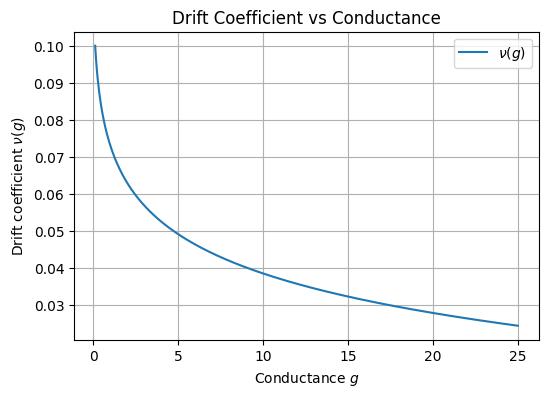

In [2]:
def nu(g):
    """ Calculate the drift coefficient nu for a given conductance g. """
    g_rel = (g - g_min) / (g_max - g_min)
    return (-0.0155 * np.log(g_rel ** 1.0 + 0.00762)) + 0.0244
    #return -0.0757 * g_rel + 0.1

def dnu_dg(g):
    g_rel = (g - g_min) / (g_max - g_min)
    return -0.0155 / (g_rel + 0.00762) * (1 / (g_max - g_min))

def f_prime(g):
    return tau**(-nu(g)) * (1 - g * np.log(tau) * dnu_dg(g))

def drift(g, tau_val):
    """ Calculate the drift coefficient for a given conductance g. """
    return g * (tau_val ** -nu(g))

""" Analysis settings """
g_min, g_max = .1, 25   # minimum and maximum conductance in uS
N = 500                    # resolution of the grid
target_time = 2.628e+6
t0 = 20
tau = 1 + target_time / t0                  # drift time factor: tau = 1 + t_inf / t_0
nu_amp = nu(g_max)               # amplification exponent
beta = 1 / (g_max - g_min)           # differential conductance to weight conversion scale
amp = nu(g_max)             # amplitude of the drift coefficient

test_g = np.linspace(g_min, g_max, N)  # conductance values for testing
# Plot G-Nu relationship
plt.figure(figsize=(6, 4))
plt.plot(test_g, nu(test_g), label=r'$\nu(g)$')
plt.xlabel('Conductance $g$')
plt.ylabel(r'Drift coefficient $\nu(g)$')
plt.title('Drift Coefficient vs Conductance')
plt.grid(True)
plt.legend()
plt.show()


### Mapping test

## 1. Uniform drift coefficients for various g_min, g_max, and G-nu relations


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

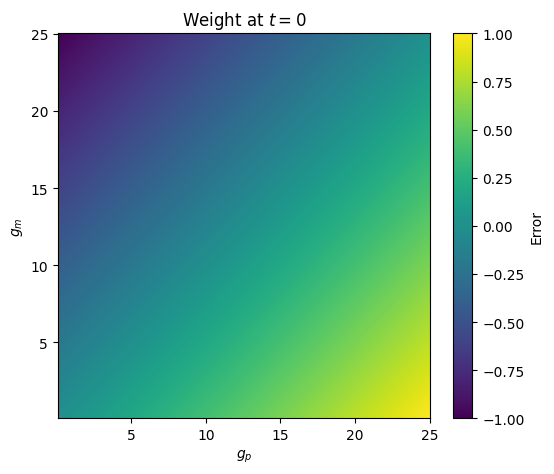

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

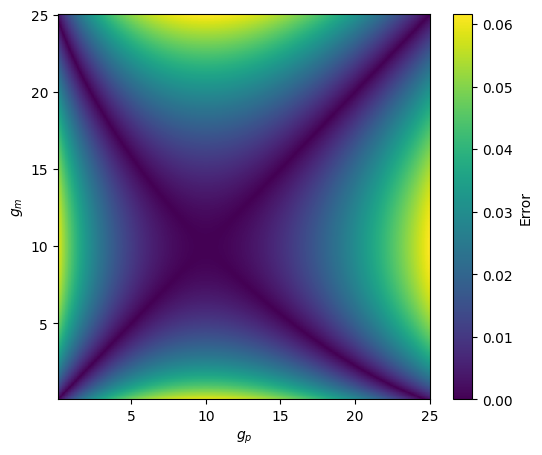

In [5]:
gp = np.linspace(g_min, g_max, N)  # conductance grid g-plus
gm = np.linspace(g_min, g_max, N)  # conductance grid g-minus
GP, GM = np.meshgrid(gp, gm)

# initial differential weight
W0 = (GP - GM) * beta
# print(type(W0))
# Plot the weight as a heatmap
plt.figure(figsize=(6, 5))
pcm = plt.pcolormesh(GP, GM, W0, shading='auto')
plt.xlabel('$g_p$')
plt.ylabel('$g_m$')
plt.title(r'Weight at $t=0$')
plt.colorbar(pcm, label='Error')
plt.show()

# drifted conductance and differential weight
GP_t = drift(GP, tau)
GM_t = drift(GM, tau)
W_t = (GP_t - GM_t) * beta
W_t_amp = W_t * (tau ** amp)


# Compute absolute error between initial and drifted+amplified weight
error = np.abs(W0 - W_t_amp)

# Plot the error as a heatmap
plt.figure(figsize=(6, 5))
pcm = plt.pcolormesh(GP, GM, error, shading='auto')
plt.xlabel('$g_p$')
plt.ylabel('$g_m$')
# plt.title(r'Absolute Error')
plt.colorbar(pcm, label='Error')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

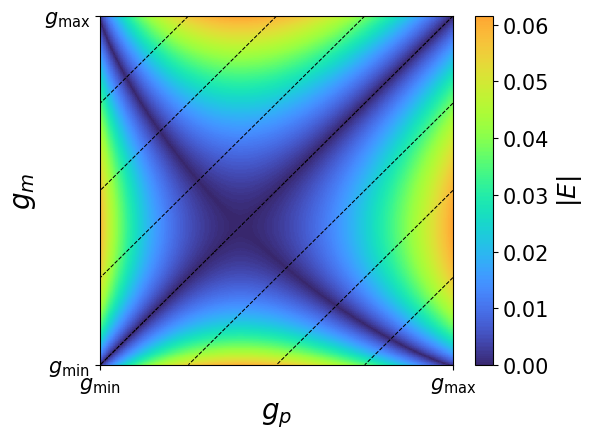

In [28]:
# Set font globally
# plt.rcParams['font.family'] = 'Helvetica'
# fallback if Helvetica not found
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.figure(figsize=(6, 4.5))
weights = beta * (GP - GM)
iso_weights = np.arange(weights.min(), weights.max() + 0.25, 0.25)

# Main colormap
import matplotlib.colors as mcolors
base_cmap = plt.get_cmap('turbo')
colors = base_cmap(np.linspace(0.03, 0.7, 256))   # 0.8 이후는 잘라냄
turbo_cut = mcolors.LinearSegmentedColormap.from_list('turbo_cut', colors)
pcm = plt.pcolormesh(GP, GM, error, shading='auto', cmap=turbo_cut)

# Axis labels
plt.xlabel(r'$g_p$', fontsize=20, fontweight='bold')
plt.ylabel(r'$g_m$', fontsize=20, fontweight='bold')

# Tick settings: show only g_min and g_max
plt.xticks([GP.min(), GP.max()], [r'$g_{\min}$', r'$g_{\max}$'],
           fontsize=15, fontweight='bold')
plt.yticks([GM.min(), GM.max()], [r'$g_{\min}$', r'$g_{\max}$'],
           fontsize=15, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(pcm)
cbar.set_label(r'$|E|$', fontsize=18, fontweight='bold')
cbar.ax.tick_params(labelsize=15) 
# for t in cbar.ax.get_yticklabels():
#     t.set_fontweight('bold')

# Iso-weight contour lines
CS = plt.contour(
    GP, GM, weights, 
    levels=iso_weights, 
    colors='k', 
    linewidths=.75,
    linestyles='dashed'   # force all solid
)
# plt.clabel(CS, inline=False, fontsize=12, fmt="%.2f", colors='k')

plt.tight_layout()
plt.savefig("gpgm_contour.png", dpi=300, bbox_inches='tight')
plt.show()



findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

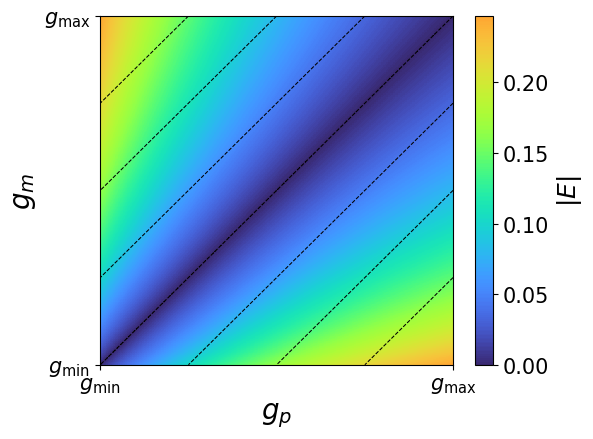

In [27]:
# Set font globally

# drifted conductance and differential weight
GP_t = drift(GP, tau)
GM_t = drift(GM, tau)
W_t = (GP_t - GM_t) * beta
W_t_amp = W_t * (tau ** amp)

# Compute absolute error between initial and drifted+amplified weight
error_naive = np.abs(W0 - W_t)

# color map
import matplotlib.colors as mcolors

base_cmap = plt.get_cmap('turbo')
colors = base_cmap(np.linspace(0.03, 0.7, 256))   # 0.8 이후는 잘라냄
turbo_cut = mcolors.LinearSegmentedColormap.from_list('turbo_cut', colors)

# plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.figure(figsize=(6, 4.5))
weights = beta * (GP - GM)
iso_weights = np.arange(weights.min(), weights.max() + 0.25, 0.25)
# Main colormap
pcm = plt.pcolormesh(GP, GM, error_naive, shading='auto', cmap=turbo_cut)

# Axis labels
plt.xlabel(r'$g_p$', fontsize=20, fontweight='bold')
plt.ylabel(r'$g_m$', fontsize=20, fontweight='bold')

# Tick settings: show only g_min and g_max
plt.xticks([GP.min(), GP.max()], [r'$g_{\min}$', r'$g_{\max}$'],
           fontsize=15, fontweight='bold')
plt.yticks([GM.min(), GM.max()], [r'$g_{\min}$', r'$g_{\max}$'],
           fontsize=15, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(pcm, ticks=np.linspace(0, 0.25, 6))
cbar.set_label(r'$|E|$', fontsize=18, fontweight='bold')
cbar.ax.tick_params(labelsize=15) 
# for t in cbar.ax.get_yticklabels():
#     t.set_fontweight('bold')

# Iso-weight contour lines
CS = plt.contour(
    GP, GM, weights, 
    levels=iso_weights, 
    colors='k', 
    linewidths=.75,
    linestyles='dashed'   # force all solid
)
# plt.clabel(CS, inline=False, fontsize=12, fmt="%.2f", colors='k')

plt.tight_layout()
plt.savefig("gpgm_contour_wo_amp.png", dpi=300, bbox_inches='tight')
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

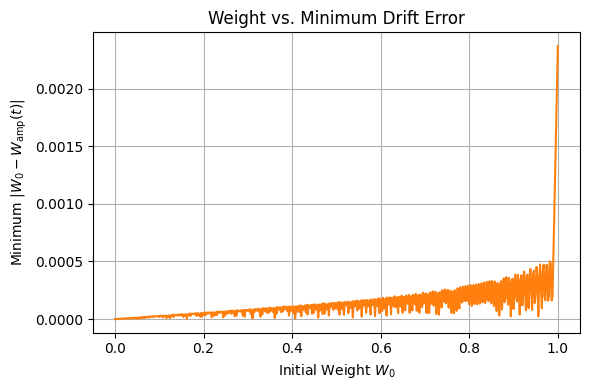

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

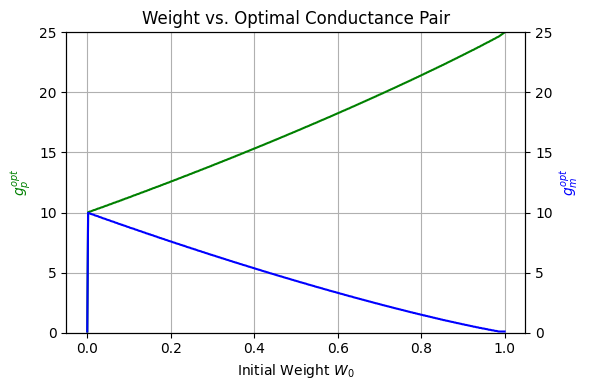

In [13]:
""" Minimum weight change analysis """

# consider only for positive weights: differential pair behavior is symmetric
mask = W0 >= 0
W0_p = W0[mask]
err_p = error[mask]
GP_p  = GP[mask]
GM_p  = GM[mask]

# unique sorted weights
interp_err = RegularGridInterpolator((gp, gm), error, method='linear', bounds_error=False, fill_value=np.nan)
W0_vals = np.unique(W0_p)

# allocate results
min_errors = np.zeros_like(W0_vals)
gp_opt     = np.zeros_like(W0_vals)
gm_opt     = np.zeros_like(W0_vals)

for i, w in enumerate(W0_vals):
    delta_g = w / beta
    gm_line = np.linspace(g_min, g_max - delta_g, 1000)
    gp_line = gm_line + delta_g

    pts = np.vstack((gp_line, gm_line)).T
    errs_line = interp_err(pts)

    idx_min = np.nanargmin(errs_line)
    min_errors[i] = errs_line[idx_min]
    gp_opt[i] = gp_line[idx_min]
    gm_opt[i] = gm_line[idx_min]
""" 
# for each weight, find the gp,gm entry with minimal error
for i, w in enumerate(W0_vals):
    idx    = np.isclose(W0_p, w)
    sub_err = err_p[idx]
    sub_gp  = GP_p[idx]
    sub_gm  = GM_p[idx]
    best   = np.argmin(sub_err)
    min_errors[i] = sub_err[best]
    gp_opt[i]     = sub_gp[best]
    gm_opt[i]     = sub_gm[best] """

plt.figure(figsize=(6,4))
plt.plot(W0_vals, min_errors, color='C1')
plt.xlabel('Initial Weight $W_0$')
plt.ylabel('Minimum $|W_0 - W_{\\mathrm{amp}}(t)|$')
plt.title('Weight vs. Minimum Drift Error')
plt.grid(True)
plt.tight_layout()
plt.show()

# Figure 2: W0 vs. optimal gp & gm (dual y-axis)
fig, ax1 = plt.subplots(figsize=(6,4))
ax2 = ax1.twinx()
ax1.plot(W0_vals, gp_opt, 'g-', label='$g_p^{opt}$')
ax2.plot(W0_vals, gm_opt, 'b-', label='$g_m^{opt}$')
ax1.set_xlabel('Initial Weight $W_0$')
ax1.set_ylabel('$g_p^{opt}$', color='g')
ax2.set_ylabel('$g_m^{opt}$', color='b')
ax1.set_ylim(0, g_max)
ax2.set_ylim(0, g_max)
plt.title('Weight vs. Optimal Conductance Pair')
ax1.grid(True)
fig.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

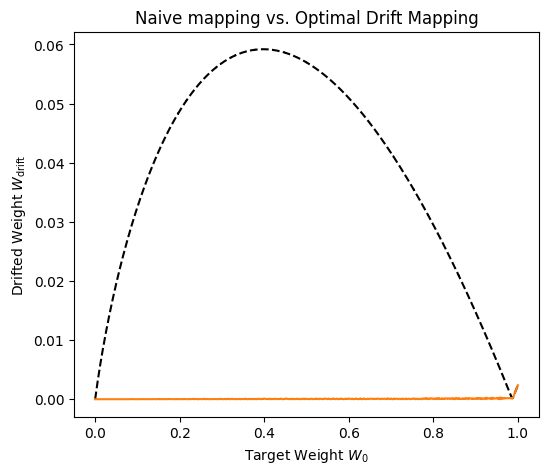

In [14]:
""" optimal line test """

gp_naive = W0_vals / beta + g_min
gm_naive = g_min

gp_naive_drifted = drift(gp_naive, tau)
gm_naive_drifted = drift(gm_naive, tau)

gp_opt_drifted = drift(gp_opt, tau)
gm_opt_drifted = drift(gm_opt, tau)


plt.figure(figsize=(6, 5))
plt.plot(W0_vals, abs(W0_vals - beta * tau ** amp * (gp_naive_drifted - gm_naive_drifted)), 'k--', label='Naive Drift Line')
plt.plot(W0_vals, abs(W0_vals - beta * tau ** amp * (gp_opt_drifted - gm_opt_drifted)), 'C1', label='Minimum Drift Error')
plt.xlabel('Target Weight $W_0$')
plt.ylabel('Drifted Weight $W_{\\mathrm{drift}}$')
plt.title(r'Naive mapping vs. Optimal Drift Mapping')
plt.show()



findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

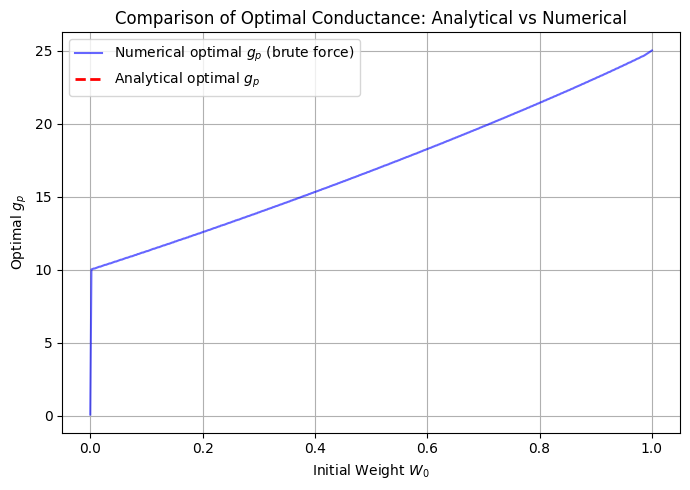

In [15]:
""" Mathematical derivation of optimal conductance pair """

def dnu_dg(g):
    g_rel = (g - g_min) / (g_max - g_min)
    return -0.0155 / (g_rel + 0.00762) * (1/(g_max - g_min))

# Optimal condition function F(g)=0
def optimal_cond(g):
    return tau**(nu_amp + nu(g)) * (1 + g*np.log(tau)*dnu_dg(g)) - 1

# Solve optimal condition numerically
g_search = np.linspace(g_min, g_max, 500)
g_opt_analytical = []
W0_analytical = []

# Numerically solve for optimal g values
for i in range(len(g_search)-1):
    g_left, g_right = g_search[i], g_search[i+1]
    if optimal_cond(g_left)*optimal_cond(g_right) < 0:  # a root exists here
        root = brentq(optimal_cond, g_left, g_right)
        g_opt_analytical.append(root)
        W0_analytical.append(beta * (root - g_min))

# Convert to arrays
g_opt_analytical = np.array(g_opt_analytical)
W0_analytical = np.array(W0_analytical)

# Existing numerical data (from brute-force grid search)
# Assuming you've computed these earlier as gp_opt and W0_vals
# gp_opt, W0_vals (from your previous brute-force analysis)

# Plot both analytical and numerical results together
plt.figure(figsize=(7,5))
plt.plot(W0_vals, gp_opt, label='Numerical optimal $g_{p}$ (brute force)', color='blue', alpha=0.6)
plt.plot(W0_analytical, g_opt_analytical, 'r--', label='Analytical optimal $g_{p}$', linewidth=2)
plt.xlabel('Initial Weight $W_0$')
plt.ylabel('Optimal $g_{p}$')
plt.title('Comparison of Optimal Conductance: Analytical vs Numerical')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica, Arial
findfont: Generic family 'sans-serif' not found because none of the foll

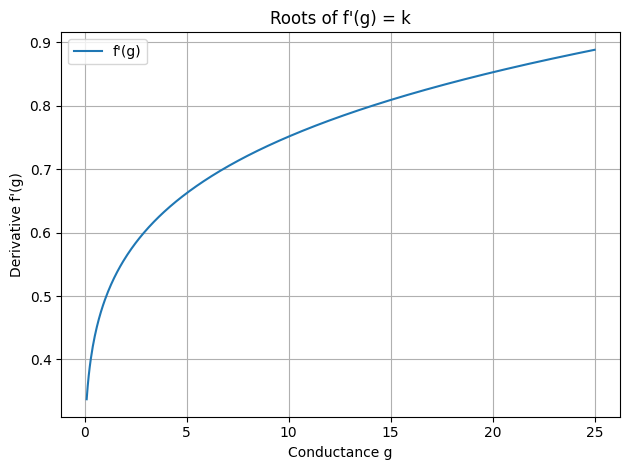

In [16]:
gs = np.linspace(g_min, g_max, N)
fp_vals = f_prime(gs)
""" 
roots = []
for i in range(N - 1):
    if (fp_vals[i] - k) * (fp_vals[i+1] - k) < 0:
        root = brentq(lambda x: f_prime(x) - k, gs[i], gs[i+1])
        roots.append(root)
 """

plt.figure()
plt.plot(gs, fp_vals, label="f'(g)")
""" plt.axhline(k, linestyle='--', label='k = tau^{-nu_amp}')
plt.scatter(roots, [k]*len(roots), marker='o', label='roots') """
plt.xlabel('Conductance g')
plt.ylabel("Derivative f'(g)")
plt.title("Roots of f'(g) = k")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
